# Phase 4 - Validation & Visualization

Notebook ini fokus pada validasi model XGBoost dan visualisasi hasil prediksi nutmeg.

**Checklist:**
- SHAP summary plot + error analysis (residual tertinggi)
- Decile calibration chart
- Top players: expected vs actual (test window 1-15 Jul 2024)


In [1]:
# Core libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Viz defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data + model
player_match = pd.read_csv("data/processed/player_match_features.csv")
predictions_df = pd.read_csv("data/processed/final_predictions.csv")
xgb = joblib.load("data/xgb_model.pkl")

# Helper: find date column consistently
DATE_COL_CANDIDATES = ["match_date", "date", "match_datetime"]

def get_date_col(df: pd.DataFrame) -> str:
    for col in DATE_COL_CANDIDATES:
        if col in df.columns:
            return col
    raise ValueError("No match date column found. Expected one of: %s" % DATE_COL_CANDIDATES)

# Explicit feature columns (avoid accidental leakage)
FEATURE_COLS = [
    "rolling_nutmeg_rate_last5",
    "rolling_dribbles_last5",
    "career_nutmeg_rate",
    "career_dribble_success_rate",
    "opponent_duel_win_rate",
    "match_number",
]

# Helper: align features to model if it stores feature names
def align_features_to_model(X: pd.DataFrame, model) -> pd.DataFrame:
    if hasattr(model, "feature_names_in_"):
        missing = [c for c in model.feature_names_in_ if c not in X.columns]
        if missing:
            raise ValueError("Missing required features for model: %s" % missing)
        return X[list(model.feature_names_in_)]

    booster = getattr(model, "get_booster", None)
    if booster is not None:
        feature_names = model.get_booster().feature_names
        if feature_names:
            missing = [c for c in feature_names if c not in X.columns]
            if missing:
                raise ValueError("Missing required features for model: %s" % missing)
            return X[feature_names]

    return X


In [2]:
# Build test window (1-15 Jul 2024) and predictions
DATE_COL = get_date_col(player_match)
player_match[DATE_COL] = pd.to_datetime(player_match[DATE_COL], errors="coerce")

# Align predictions with player_match if needed
# if len(predictions_df) == len(player_match) and "prediction" not in player_match.columns:
#     # Prefer explicit column name if present
#     pred_col = "prediction" if "prediction" in predictions_df.columns else "predicted_nutmegs"
#     if pred_col in predictions_df.columns:
#         player_match["prediction"] = predictions_df[pred_col].values

# merge berdasarkan ID unik.
# if "prediction" not in player_match.columns:
#     pred_col = "prediction" if "prediction" in predictions_df.columns else "predicted_nutmegs"
#     # Asumsi ada player_id dan match_id di kedua dataframe
#     merge_keys = [k for k in ["player_id", "match_id"] if k in predictions_df.columns and k in player_match.columns]
#     if merge_keys:
#         player_match = player_match.merge(
#             predictions_df[merge_keys + [pred_col]], 
#             on=merge_keys, 
#             how="left"
#         )
#         player_match.rename(columns={pred_col: "prediction"}, inplace=True)

# merge berdasarkan ID unik.
if "prediction" not in player_match.columns:
    # Daftar kandidat nama kolom prediksi yang mungkin ada di final_predictions.csv
    possible_pred_cols = ["prediction", "predicted_nutmegs", "pred", "expected_nutmegs", "match_nutmegs_pred"]
    
    pred_col = None
    for col in possible_pred_cols:
        if col in predictions_df.columns:
            pred_col = col
            break
            
    # Jika kolom prediksi ditemukan, lakukan merge
    if pred_col:
        merge_keys = [k for k in ["player_id", "match_id"] if k in predictions_df.columns and k in player_match.columns]
        if merge_keys:
            player_match = player_match.merge(
                predictions_df[merge_keys + [pred_col]], 
                on=merge_keys, 
                how="left",
            )
            player_match.rename(columns={pred_col: "prediction"}, inplace=True)
            print(f"Berhasil merge kolom '{pred_col}' sebagai 'prediction'.")
    else:
        print(f"Kolom prediksi tidak ditemukan di predictions_df. Kolom yang tersedia: {predictions_df.columns.tolist()}")
        print("Sistem akan melakukan generate ulang prediksi menggunakan model XGBoost.")

# Target column
TARGET_COL_CANDIDATES = ["match_nutmegs", "nutmegs", "y"]
TARGET_COL = None
for col in TARGET_COL_CANDIDATES:
    if col in player_match.columns:
        TARGET_COL = col
        break
if TARGET_COL is None:
    raise ValueError("Target column not found. Expected one of: %s" % TARGET_COL_CANDIDATES)

# If prediction not available, generate with model
if "prediction" not in player_match.columns:
    feature_cols = FEATURE_COLS
    X_all = align_features_to_model(player_match[feature_cols], xgb)
    player_match["prediction"] = xgb.predict(X_all)

# Define test window
test_start = pd.Timestamp("2024-07-01")
test_end = pd.Timestamp("2024-07-15")

is_test = (player_match[DATE_COL] >= test_start) & (player_match[DATE_COL] <= test_end)
player_match["set"] = np.where(is_test, "test", "train")

# Instruksi pemetaan (mapping) deterministik
print(f"TARGET_COL terdeteksi sebagai: {TARGET_COL}")

# --- FIX KONTAMINASI DATA ---
# Ubah nilai string/boolean 'True' dan 'False' kembali ke representasi angka 1 dan 0
mapping_dict = {'True': 1, 'False': 0, True: 1, False: 0}
player_match[TARGET_COL] = player_match[TARGET_COL].replace(mapping_dict)

# Setelah di-map, cast seluruh kolom ke float agar seragam dengan kolom prediksi
player_match[TARGET_COL] = player_match[TARGET_COL].astype(float)
# ----------------------------

# Residuals (actual - predicted)
player_match["residual"] = player_match[TARGET_COL] - player_match["prediction"]
player_match["abs_residual"] = player_match["residual"].abs()

# Quick sanity checks
print("Rows:", len(player_match))
print("Test rows:", is_test.sum())
print("Target col:", TARGET_COL)
# Residuals (actual - predicted)
player_match["residual"] = player_match[TARGET_COL] - player_match["prediction"]
player_match["abs_residual"] = player_match["residual"].abs()

# Quick sanity checks
print("Rows:", len(player_match))
print("Test rows:", is_test.sum())
print("Target col:", TARGET_COL)


Kolom prediksi tidak ditemukan di predictions_df. Kolom yang tersedia: ['player_id', 'player', 'team', 'match_id', 'match_date', 'opponent', 'competition', 'match_dribbles', 'match_nutmegs', 'match_successful_dribbles', 'rolling_nutmegs_last5', 'rolling_dribbles_last5', 'rolling_nutmeg_rate_last5', 'match_number', 'career_nutmeg_rate', 'career_dribble_success_rate', 'opponent_duel_win_rate', 'predicted_nutmegs_next_match']
Sistem akan melakukan generate ulang prediksi menggunakan model XGBoost.
TARGET_COL terdeteksi sebagai: match_nutmegs
Rows: 664
Test rows: 142
Target col: match_nutmegs
Rows: 664
Test rows: 142
Target col: match_nutmegs


## 1) Error Analysis - Residual Tertinggi

Cari match di mana prediksi paling meleset (abs residual terbesar) di **test set**.


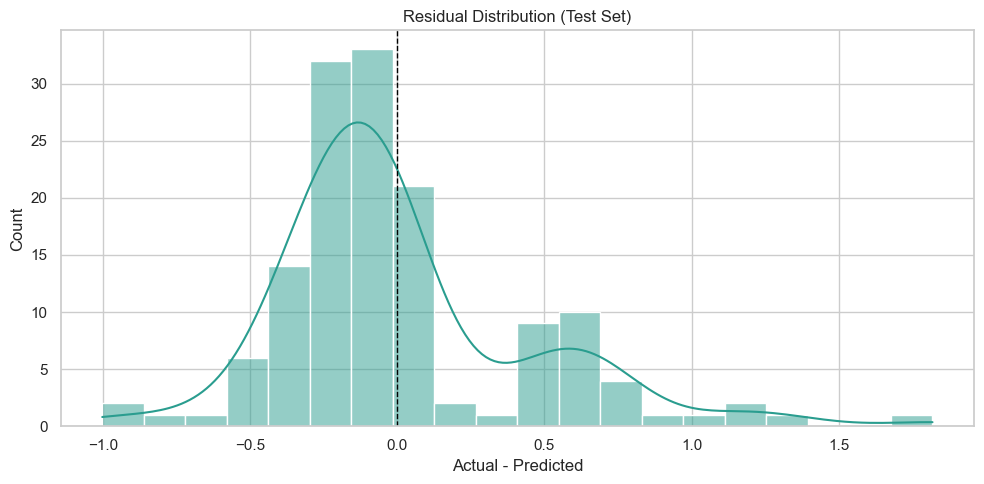

In [3]:
# Pick columns to display if they exist
DISPLAY_COLS = [
    "player_name",
    "team",
    "opponent",
    "competition",
    "match_stage",
    DATE_COL,
    TARGET_COL,
    "prediction",
    "residual",
    "abs_residual",
]
DISPLAY_COLS = [c for c in DISPLAY_COLS if c in player_match.columns]

error_table = (
    player_match[player_match["set"] == "test"]
    .sort_values("abs_residual", ascending=False)
    .head(15)
    .loc[:, DISPLAY_COLS]
)

error_table

# Optional: residual distribution
plt.figure(figsize=(10, 5))
sns.histplot(
    data=player_match[player_match["set"] == "test"],
    x="residual",
    bins=20,
    kde=True,
    color="#2a9d8f",
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Distribution (Test Set)")
plt.xlabel("Actual - Predicted")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 2) SHAP Summary Plot

Menjelaskan fitur mana yang paling mendorong prediksi model.


d:\toni\nutmeg_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d:\toni\nutmeg_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


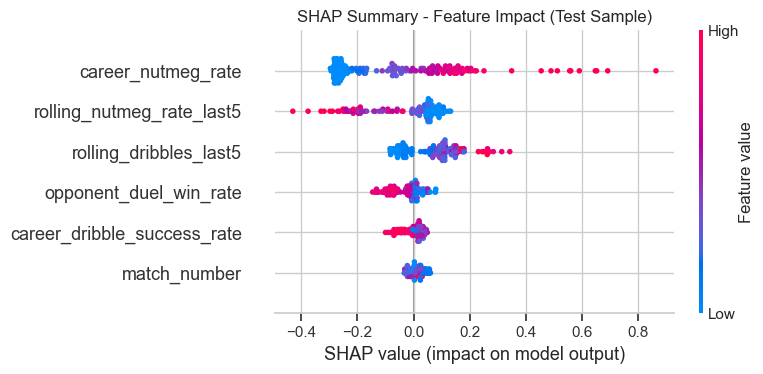

In [4]:
# SHAP summary plot (tree explainer)
import shap

# Build feature matrix for test set
feature_cols = FEATURE_COLS
X_all = align_features_to_model(player_match[feature_cols], xgb)
X_test = X_all[player_match["set"] == "test"].copy()

# Sample for speed if needed
SAMPLE_N = 200 if len(X_test) > 200 else len(X_test)
X_sample = X_test.sample(SAMPLE_N, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary - Feature Impact (Test Sample)")
plt.tight_layout()
plt.show()


## 3a) Decile Calibration Chart

Mengecek apakah prediksi model sudah terkalibrasi (mean pred vs mean aktual per decile).


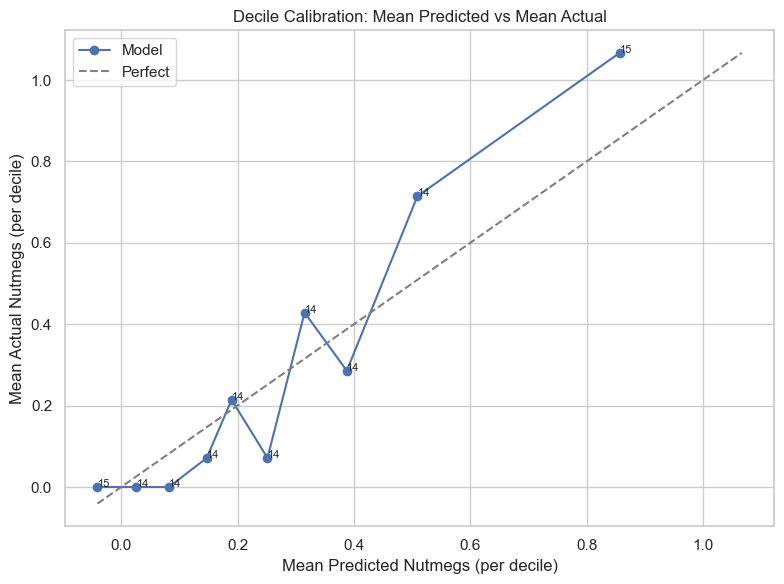

In [5]:
test_df = player_match[player_match["set"] == "test"].copy()

# Build deciles based on predicted values
n_bins = 10
# qcut may drop bins if duplicates; handle safely
try:
    test_df["pred_decile"] = pd.qcut(test_df["prediction"], q=n_bins, labels=False)
except ValueError:
    # Fallback to rank-based bins
    test_df["pred_decile"] = pd.qcut(
        test_df["prediction"].rank(method="first"), q=n_bins, labels=False
    )

calib = (
    test_df.groupby("pred_decile")
    .agg(
        mean_pred=("prediction", "mean"),
        mean_actual=(TARGET_COL, "mean"),
        count=("prediction", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(8, 6))
plt.plot(calib["mean_pred"], calib["mean_actual"], marker="o", label="Model")

# Perfect calibration line
min_val = min(calib["mean_pred"].min(), calib["mean_actual"].min())
max_val = max(calib["mean_pred"].max(), calib["mean_actual"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray", label="Perfect")

for _, row in calib.iterrows():
    plt.text(row["mean_pred"], row["mean_actual"], str(int(row["count"])), fontsize=8)

plt.title("Decile Calibration: Mean Predicted vs Mean Actual")
plt.xlabel("Mean Predicted Nutmegs (per decile)")
plt.ylabel("Mean Actual Nutmegs (per decile)")
plt.legend()
plt.tight_layout()
plt.show()


## 3b) Zero-Inflation Scatter

Untuk menunjukkan secara visual betapa sulitnya memprediksi nutmeg (karena jarangnya kejadian)

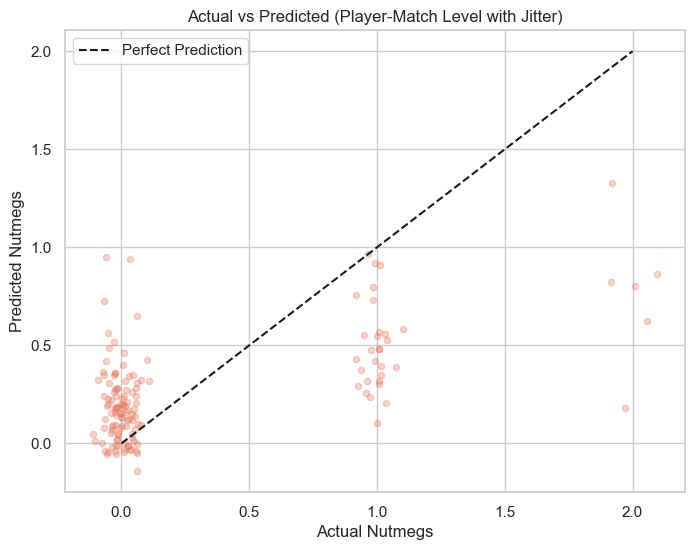

In [6]:
# Menambahkan sedikit noise (jitter) agar titik tidak menumpuk di (0,0)
import numpy as np
jitter_actual = test_df[TARGET_COL] + np.random.normal(0, 0.05, size=len(test_df))
jitter_pred = test_df["prediction"] + np.random.normal(0, 0.02, size=len(test_df))

plt.figure(figsize=(8, 6))
plt.scatter(jitter_actual, jitter_pred, alpha=0.3, color="#e76f51", s=20)
plt.plot([0, test_df[TARGET_COL].max()], [0, test_df[TARGET_COL].max()], 'k--', label="Perfect Prediction")
plt.title("Actual vs Predicted (Player-Match Level with Jitter)")
plt.xlabel("Actual Nutmegs")
plt.ylabel("Predicted Nutmegs")
plt.legend()
plt.show()

## 4) Top Players - Expected vs Actual (Test Window)

Visualisasi 20 pemain dengan **prediksi tertinggi** di test set.


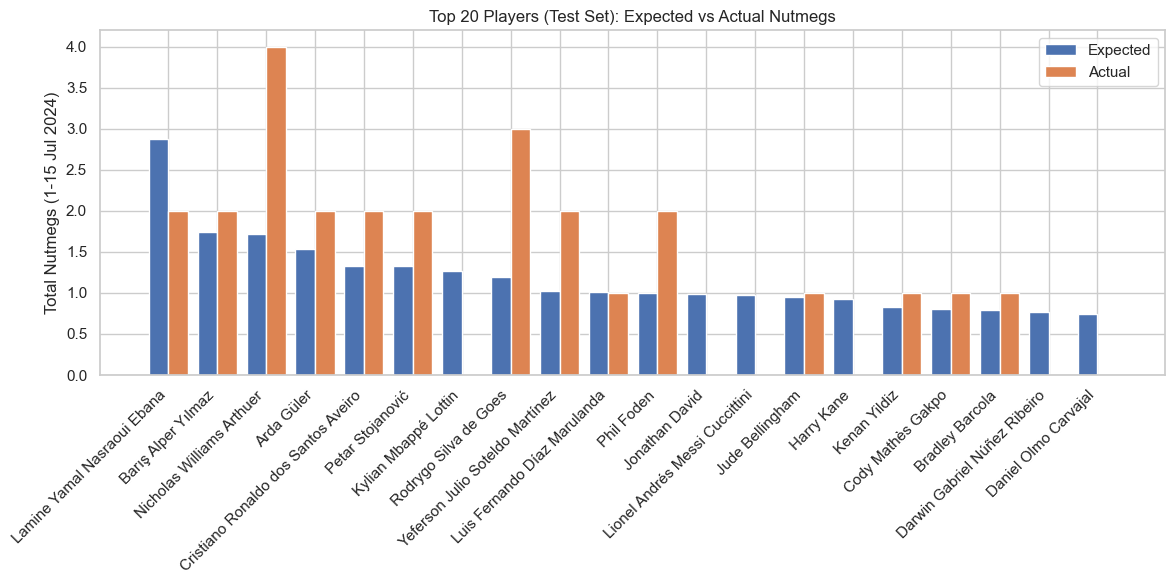

In [7]:
# Identify player column
PLAYER_COL_CANDIDATES = ["player_name", "player", "player_id"]
PLAYER_COL = None
for col in PLAYER_COL_CANDIDATES:
    if col in test_df.columns:
        PLAYER_COL = col
        break
if PLAYER_COL is None:
    raise ValueError("Player column not found. Expected one of: %s" % PLAYER_COL_CANDIDATES)

player_agg = (
    test_df.groupby(PLAYER_COL)
    .agg(
        expected=("prediction", "sum"),
        actual=(TARGET_COL, "sum"),
        matches=(TARGET_COL, "size"),
    )
    .reset_index()
)

# Top 20 by expected nutmegs
player_top = player_agg.sort_values("expected", ascending=False).head(20)

# Bar chart
x = np.arange(len(player_top))
width = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, player_top["expected"], width, label="Expected")
plt.bar(x + width / 2, player_top["actual"], width, label="Actual")

plt.xticks(x, player_top[PLAYER_COL], rotation=45, ha="right")
plt.title("Top 20 Players (Test Set): Expected vs Actual Nutmegs")
plt.ylabel("Total Nutmegs (1-15 Jul 2024)")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# untuk export aset Streamlit
import os
os.makedirs("data/streamlit_assets", exist_ok=True)

# Validation summary (RMSE/MAE) for test set
y_true = test_df[TARGET_COL]
y_pred = test_df["prediction"]
rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
mae = float(np.mean(np.abs(y_true - y_pred)))
validation_summary = pd.DataFrame(
    [
        {"metric": "RMSE", "value": rmse},
        {"metric": "MAE", "value": mae},
    ]
)

# 1. Export Error Table (untuk fitur "Where did the model fail?")
error_table.to_csv("data/streamlit_assets/error_analysis.csv", index=False)

# 2. Export Calibration Data (untuk chart kalibrasi di Streamlit)
calib.to_csv("data/streamlit_assets/calibration_curve.csv", index=False)

# 3. Export Top Players (untuk dashboard utama)
player_top.to_csv("data/streamlit_assets/top_players_expected_vs_actual.csv", index=False)

# 4. Export SHAP values (agar Streamlit tidak perlu hitung ulang TreeExplainer)
import pickle
with open("data/streamlit_assets/shap_values.pkl", "wb") as f:
    pickle.dump({"shap_values": shap_values, "X_sample": X_sample}, f)

# 5. Export validation summary (RMSE/MAE)
validation_summary.to_csv("data/streamlit_assets/validation_summary.csv", index=False)

print("Semua aset untuk Streamlit berhasil di-export!")

Semua aset untuk Streamlit berhasil di-export!
